<a href="https://colab.research.google.com/github/ayushverma1903/celebal/blob/main/week3%3CAyush_verma%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
!pip install xgboost


In [127]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

In [128]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Country-data.csv")

df.head()

Saving Country-data.csv to Country-data (1).csv
Saving data-dictionary.csv to data-dictionary (1).csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [129]:
df.shape

(167, 10)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [131]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [132]:
print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [133]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [134]:
df.duplicated().sum()

np.int64(0)

In [135]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [136]:
print("Duplicate Rows :", df.duplicated().sum())


Duplicate Rows : 0


In [137]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [138]:
country = df["country"]
X = df.drop("country", axis=1)

In [139]:
X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [140]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Successfully")

Successfully


In [141]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [142]:

scaled_df.head()



,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


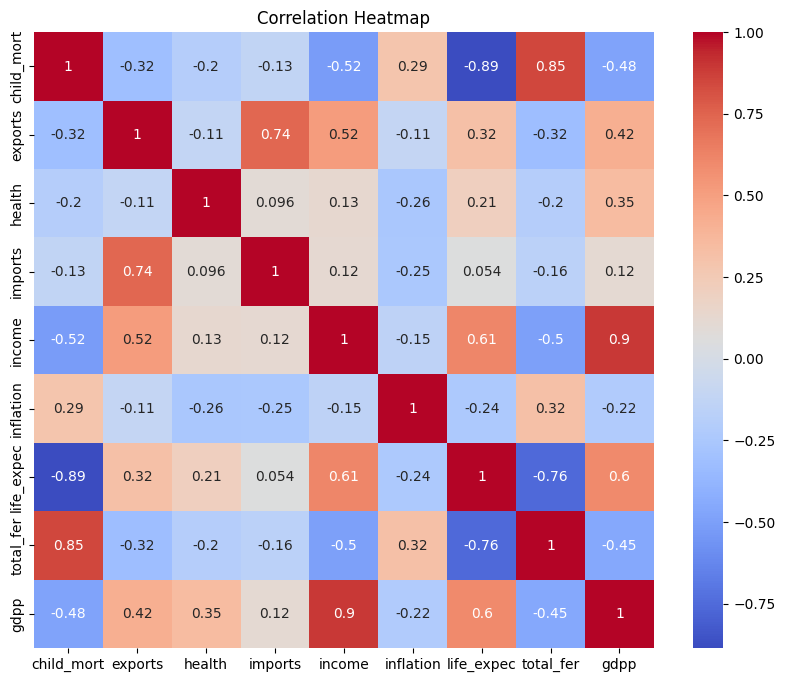

In [143]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [144]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


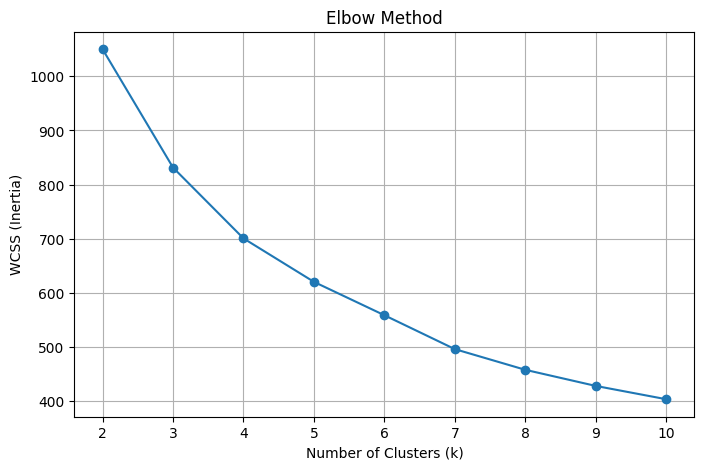

In [145]:

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

In [146]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [147]:
df["Cluster"] = clusters
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [148]:
df["Cluster"].value_counts()

,count
Cluster,
2,84
1,47
0,36


In [149]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score :", round(score,3))

Silhouette Score : 0.283


In [150]:
df.groupby("Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [151]:
dbscan = DBSCAN(eps=1.5,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = dbscan_labels
df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


In [152]:
X_pca = PCA(n_components=2).fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters
pca_df.head()

,PC1,PC2,Cluster
0,-2.913025,0.095621,1
1,0.429911,-0.588156,2
2,-0.285225,-0.455174,2
3,-2.932423,1.695555,1
4,1.033576,0.136659,2


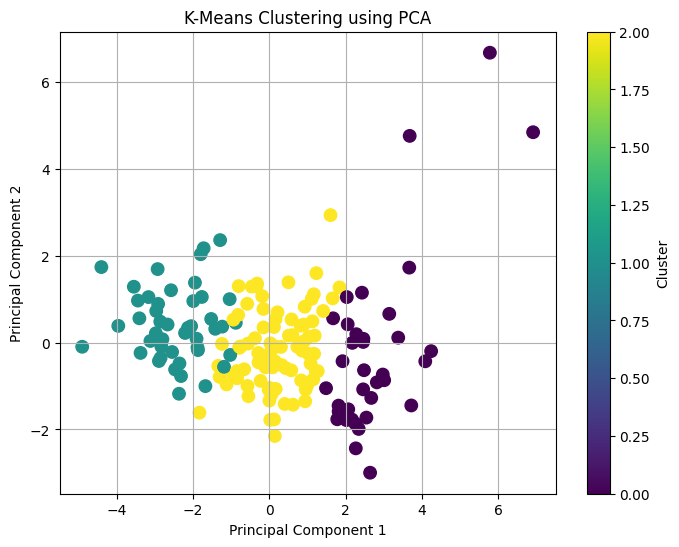

In [153]:
plt.figure(figsize=(8,6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=80
)

plt.title("K-Means Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

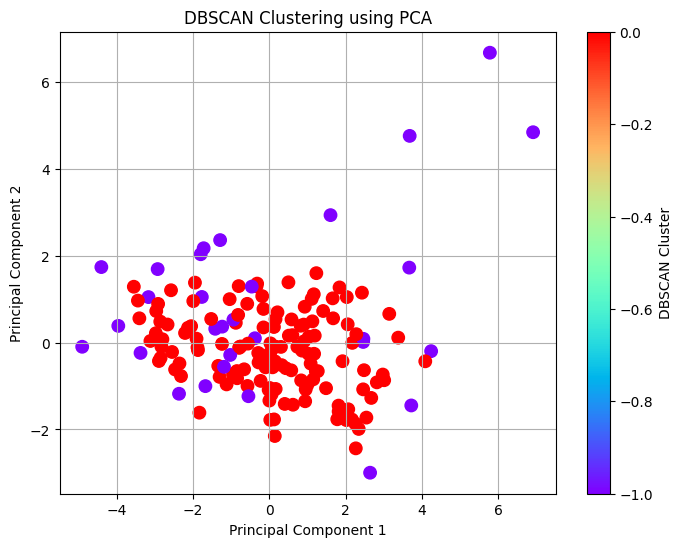

In [154]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    cmap="rainbow",
    s=80
)
plt.title("DBSCAN Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="DBSCAN Cluster")
plt.grid(True)
plt.show()

In [155]:
X = df.drop(columns=["country", "Cluster", "DBSCAN_Cluster"])
y = df["Cluster"]

In [156]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training :", X_train.shape)
print("Testing :", X_test.shape)

Training : (133, 9)
Testing : (34, 9)


In [157]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy :", round(dt_acc,4))

Decision Tree Accuracy : 1.0


In [158]:
print("Classification Report")
print(classification_report(y_test, dt_pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00        20

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [159]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy :", round(rf_acc,4))

Random Forest Accuracy : 0.9706


In [160]:
print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))


Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [161]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [162]:
xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy :", round(xgb_acc,4))
print("\nClassification Report\n")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy : 0.9706

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [163]:
results = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        dt_acc,
        rf_acc,
        xgb_acc
    ]
})
results

,Model,Accuracy
0,Decision Tree,1.000000
1,Random Forest,0.970588
2,XGBoost,0.970588


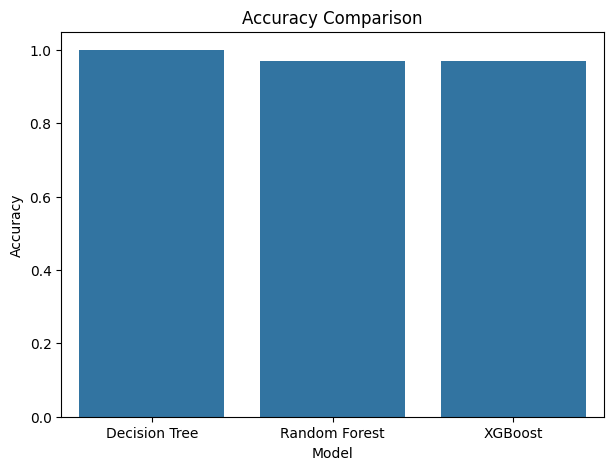

In [164]:
plt.figure(figsize=(7,5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Accuracy Comparison")
plt.show()

In [165]:
best_model = results.iloc[0]
print("Best Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"],4))

Best Model : Decision Tree
Accuracy : 1.0


[[ 8  0  0]
 [ 0  6  0]
 [ 0  1 19]]


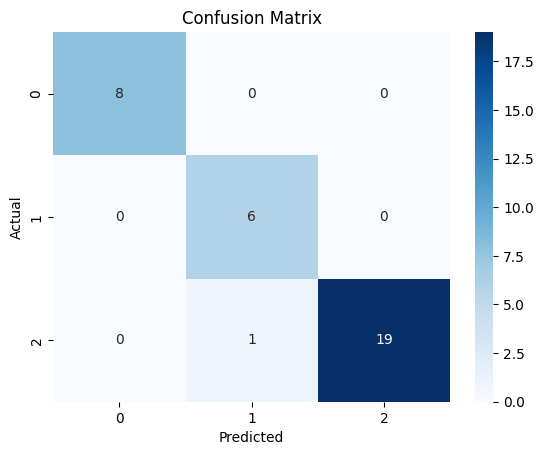

In [166]:
cm = confusion_matrix(y_test, rf_pred)
print(cm)
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [167]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(by="Importance", ascending=False)
importance

,Feature,Importance
0,child_mort,0.276790
8,gdpp,0.194674
4,income,0.167519
6,life_expec,0.157759
7,total_fer,0.141250
2,health,0.024614
5,inflation,0.015699
1,exports,0.013360
3,imports,0.008336


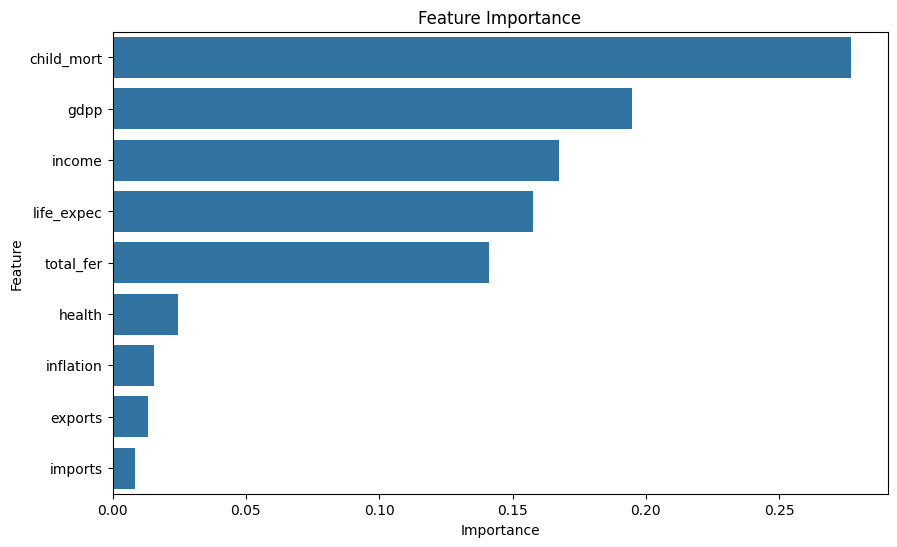

In [168]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()

In [169]:
cluster_statistics = df.groupby("Cluster").agg({
    "child_mort":"mean",
    "exports":"mean",
    "health":"mean",
    "imports":"mean",
    "income":"mean",
    "inflation":"mean",
    "life_expec":"mean",
    "total_fer":"mean",
    "gdpp":"mean"
})
cluster_statistics

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


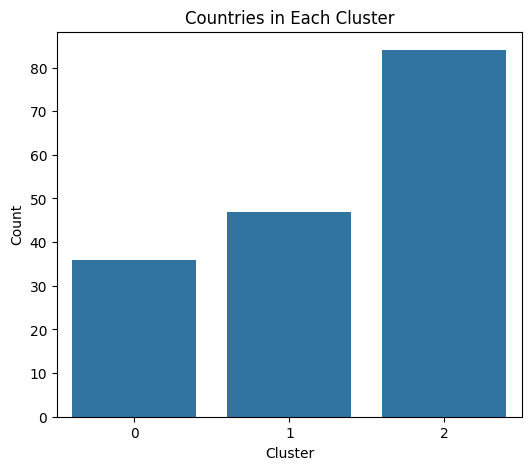

In [170]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x="Cluster"
)
plt.title("Countries in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [171]:
for cluster in sorted(df["Cluster"].unique()):
    print("="*60)
    print(f"Cluster {cluster}")
    print("="*60)
    countries = df[df["Cluster"] == cluster]["country"].tolist()
    print(countries)
    print("\n")

Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']


Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'To

In [172]:
print("PROJECT OBSERVATIONS")
print("="*60)

print("\n1. K-Means clustering successfully divided the countries into three meaningful groups based on socio-economic indicators.")

print("\n2. Countries with high GDP, income, exports and life expectancy belong to the developed cluster.")

print("\n3. Countries with high child mortality, high fertility rate and low life expectancy belong to the underdeveloped cluster.")

print("\n4. The Silhouette Score indicates that the K-Means clustering produced meaningful and reasonably well-separated clusters.")

print("\n5. DBSCAN detected dense groups of countries and also identified noise or outlier countries that do not belong to any dense cluster.")

print("\n6. Among the classification models, Random Forest and XGBoost achieved higher accuracy than Decision Tree, showing the effectiveness of ensemble learning.")

PROJECT OBSERVATIONS

1. K-Means clustering successfully divided the countries into three meaningful groups based on socio-economic indicators.

2. Countries with high GDP, income, exports and life expectancy belong to the developed cluster.

3. Countries with high child mortality, high fertility rate and low life expectancy belong to the underdeveloped cluster.

4. The Silhouette Score indicates that the K-Means clustering produced meaningful and reasonably well-separated clusters.

5. DBSCAN detected dense groups of countries and also identified noise or outlier countries that do not belong to any dense cluster.

6. Among the classification models, Random Forest and XGBoost achieved higher accuracy than Decision Tree, showing the effectiveness of ensemble learning.
